# 🍷 Proyecto Senior: Predicción de Calidad de Vino con MLOps & XAI
## Fase 1: Análisis Exploratorio de Datos (EDA) e Ingeniería de Características Enológicas

**Autor:** Guillén Concepción *(Senior Data Scientist & MLOps Engineer)*  
**Dataset:** Cortez et al., UCI Machine Learning Repository (Wine Quality Dataset - ID 186)  
**Marco Teórico de Referencia:**
- **Nguyen, Dexter (Duke / TDS, 2020):** *Red Wine Quality Prediction Using Regression Modeling and Machine Learning*. Aporta el análisis bivariado y 3D de interacciones fisicoquímicas no lineales (dinámica alcohol vs acidez volátil).
- **Rachmaan, M. Arief (Medium, 2023):** *Wine Quality Prediction with Machine Learning Model*. Aporta la diagnosis del desbalance severo en calificaciones sensoriales de cata y la necesidad de métricas estratificadas.

**Objetivo Científico:** Descubrir la signatura química y las relaciones estadísticas que determinan la calidad sensorial del vino (tinto y blanco), diagnosticando desbalance de clases, correlaciones no lineales y anomalías físico-químicas antes del modelado productivo.


In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Add project root to sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.loader import load_raw_wine_data
from src.features.transformers import EnologicalFeatureEngineer

# Configure aesthetics
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

print("Environment configured successfully.")


Environment configured successfully.


### 1. Ingesta y Estructura del Dataset Unificado
El dataset unificado integra las variantes de vino tinto (1,599 observaciones) y vino blanco (4,898 observaciones), totalizando 6,497 muestras con 11 variables fisicoquímicas continuas y la variable indicadora `is_red`.


In [ ]:
df = load_raw_wine_data()
print("Dimensiones del dataset:", df.shape)
display(df.head())
print("\nTipos de datos y valores nulos:")
display(df.info())


2026-09-11 14:13:50,917 [INFO] src.data.loader: Loaded Red Wine samples: 1599
2026-09-11 14:13:50,937 [INFO] src.data.loader: Loaded White Wine samples: 4898
2026-09-11 14:13:50,940 [INFO] src.data.loader: Total unified samples: 6497 (Features: 13)


2026-09-11 14:13:50,982 [INFO] src.data.loader: Unified dataset persisted to: D:\LabD\Proyecto Odysseus\experiments\ds_mlops_Wine_Quality_Classification\data\processed\winequality_unified.parquet


Dimensiones del dataset: (6497, 13)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,is_red
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1



Tipos de datos y valores nulos:
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   ph                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  is_red                6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


None

### Diagnóstico de Integridad
- **Completitud:** 100% de datos limpios sin valores nulos ni campos corruptos.
- **Tipado:** 11 características en escala continua (float64) más el indicador binario `is_red` (int64).
- **Target (`quality`):** Puntuaciones sensoriales discretas otorgadas por un panel de al menos tres catadores, entre 0 y 10.


### 2. Distribución del Target (`quality`): Diagnóstico Crítico de Desbalance
Analizamos la frecuencia de cada nivel de calidad sensorial para dimensionar el desafío de clasificación multiclase.


2026-09-11 14:13:51,196 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-11 14:13:51,211 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-11 14:13:51,411 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-11 14:13:51,422 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


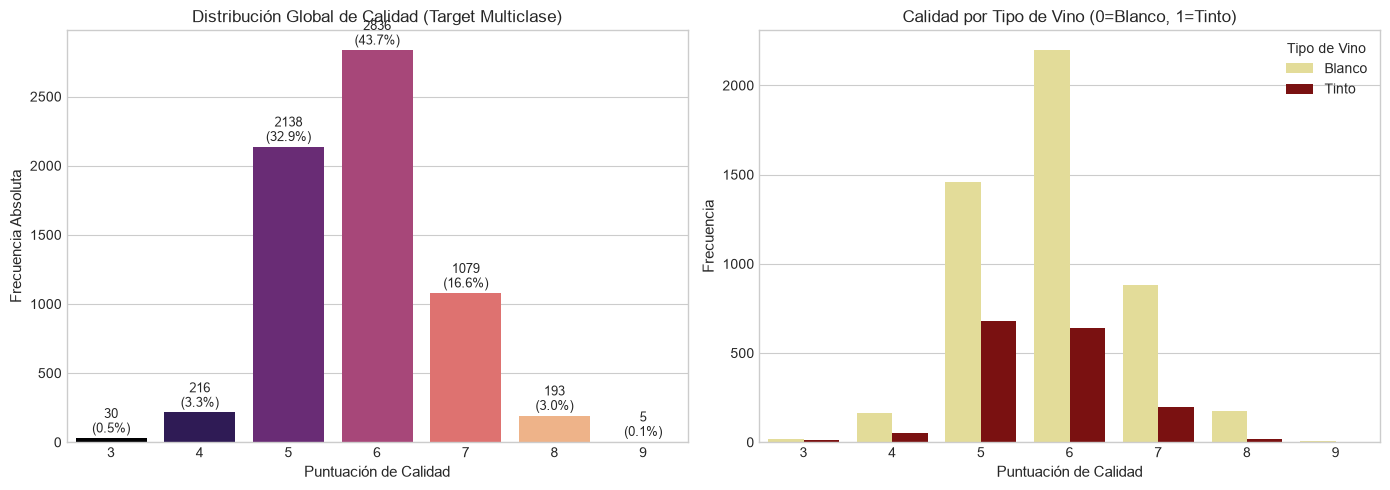

Frecuencia exacta de clases:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución Global
class_counts = df['quality'].value_counts().sort_index()
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette="magma", hue=class_counts.index, legend=False)
axes[0].set_title("Distribución Global de Calidad (Target Multiclase)")
axes[0].set_xlabel("Puntuación de Calidad")
axes[0].set_ylabel("Frecuencia Absoluta")
for i, count in enumerate(class_counts.values):
    pct = (count / len(df)) * 100
    axes[0].text(i, count + 40, f"{count}\n({pct:.1f}%)", ha='center', fontsize=9)

# Comparativa Tinto vs Blanco
sns.countplot(data=df, x='quality', hue='is_red', ax=axes[1], palette={0: "#f0e68c", 1: "#8b0000"})
axes[1].set_title("Calidad por Tipo de Vino (0=Blanco, 1=Tinto)")
axes[1].set_xlabel("Puntuación de Calidad")
axes[1].set_ylabel("Frecuencia")
axes[1].legend(title="Tipo de Vino", labels=["Blanco", "Tinto"])

plt.tight_layout()
plt.show()

print("Frecuencia exacta de clases:")
print(class_counts)


### Hallazgos de Distribución
1. **Desbalance Severo:** El 76.5% de los vinos se concentran en las notas intermedias 5 y 6 (2,138 y 2,836 muestras respectivamente).
2. **Clases Extremas Minoritarias:**
   - La nota 3 cuenta con apenas 30 registros (0.46%).
   - La nota 9 cuenta con únicamente 5 registros (0.08%).
3. **Implicación MLOps / Senior:** Un clasificador ingenuo que prediga siempre clase 6 obtendría un 43.6% de accuracy global pero fracasaría en detectar vinos defectuosos (3-4) o de excelencia (8-9). Se requiere una función de costo ponderada (`class_weight='balanced'`) y evaluación por **Macro-F1** y **Balanced Accuracy**.


### 3. Análisis de Correlación y Asociación Fisicoquímica
Evaluamos las correlaciones de Pearson entre las variables analíticas y la puntuación de calidad.


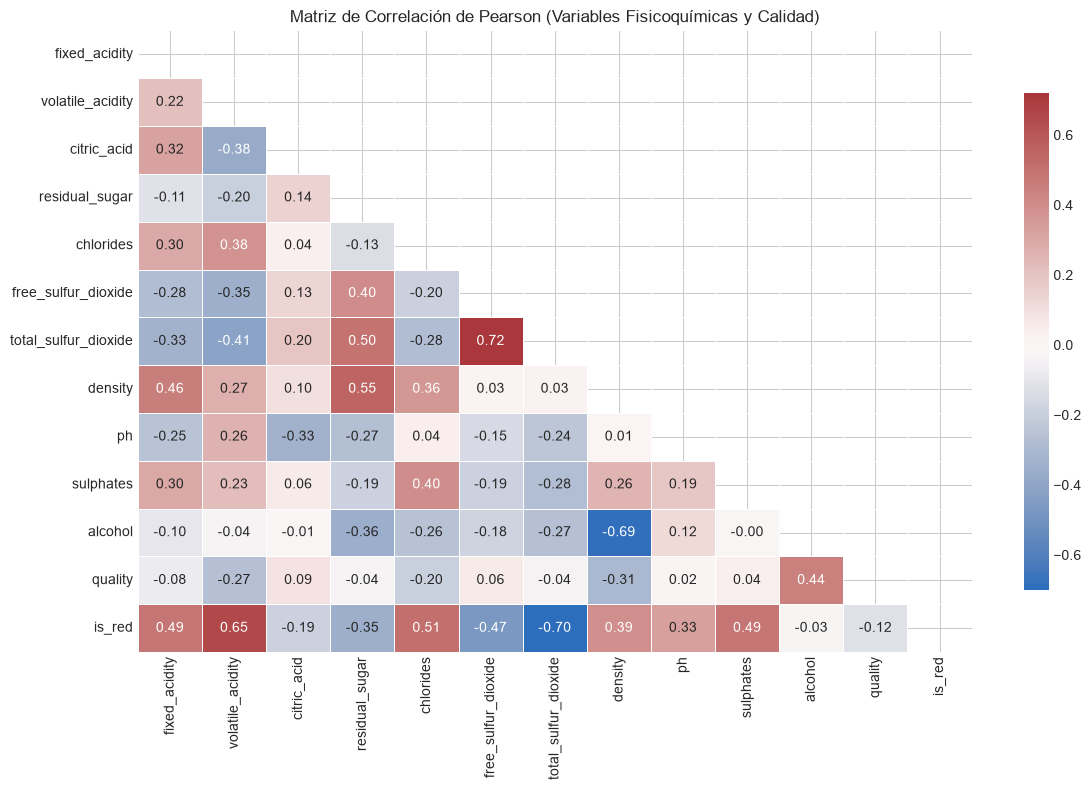

--- Correlación con la Calidad (Target) ---
alcohol                 0.444319
citric_acid             0.085532
free_sulfur_dioxide     0.055463
sulphates               0.038485
ph                      0.019506
residual_sugar         -0.036980
total_sulfur_dioxide   -0.041385
fixed_acidity          -0.076743
is_red                 -0.119323
chlorides              -0.200666
volatile_acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


In [ ]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="vlag", 
    center=0, 
    linewidths=0.5, 
    cbar_kws={"shrink": 0.8}
)
plt.title("Matriz de Correlación de Pearson (Variables Fisicoquímicas y Calidad)")
plt.tight_layout()
plt.show()

# Ranking de correlación directa con quality
target_corr = corr_matrix['quality'].drop('quality').sort_values(ascending=False)
print("--- Correlación con la Calidad (Target) ---")
print(target_corr)


### Interpretación Enológica de Correlaciones
- **Alcohol (+0.44):** Es el predictor individual más fuertemente correlacionado de manera positiva con la calidad. En vinos fermentados de alta calidad, un mayor contenido alcohólico se asocia con mejor maduración de la uva y cuerpo en boca.
- **Acidez Volátil (-0.27):** Principal vector de correlación negativa. Corresponde principalmente al ácido acético; concentraciones elevadas confieren olor avinagrado y defecto organoléptico.
- **Densidad (-0.31):** Correlación negativa impulsada por la presencia de alcohol (menos denso que el agua).
- **Dióxido de Azufre y Azúcar:** Muestran correlaciones moderadas a débiles en solitario, pero revelan fuertes discrepancias entre vinos tintos y blancos (el vino blanco utiliza significativamente más SO2 para prevenir la oxidación aromática).


### 4. Detección y Auditoría de Outliers (IQR)
Analizamos la presencia de valores atípicos mediante el método de Rango Intercuartílico (Tukey fences).


2026-09-11 14:20:06,795 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-11 14:20:06,808 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-11 14:20:06,883 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-11 14:20:06,896 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-11 14:20:06,952 [INFO] m

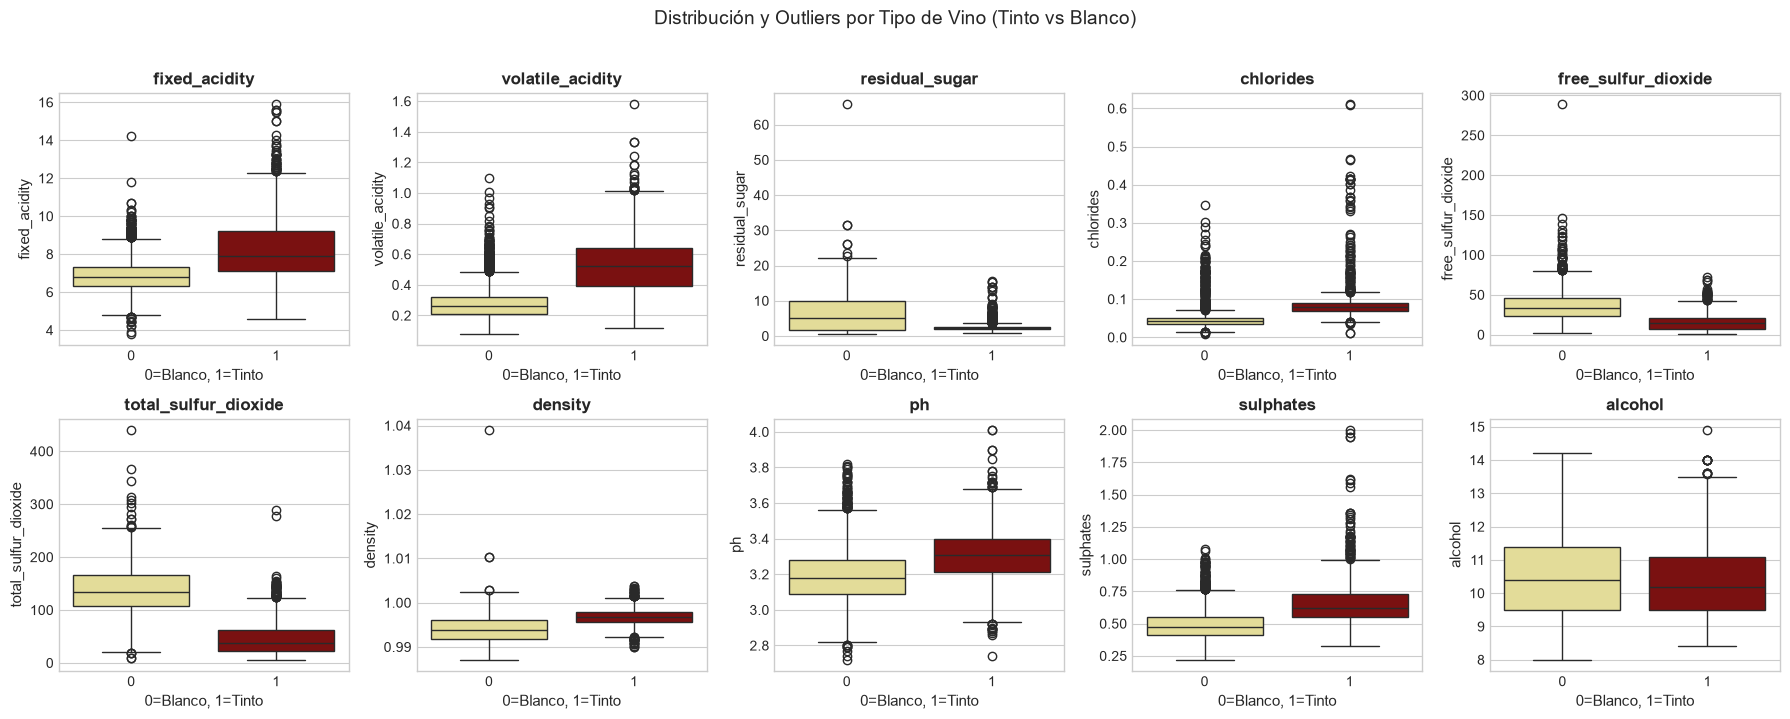

Resumen de Outliers por Variable (1.5 * IQR):
 - fixed_acidity            :  357 muestras (5.5%)
 - volatile_acidity         :  377 muestras (5.8%)
 - residual_sugar           :  118 muestras (1.8%)
 - chlorides                :  286 muestras (4.4%)
 - free_sulfur_dioxide      :   62 muestras (1.0%)
 - total_sulfur_dioxide     :   10 muestras (0.2%)
 - density                  :    3 muestras (0.0%)
 - ph                       :   73 muestras (1.1%)
 - sulphates                :  191 muestras (2.9%)
 - alcohol                  :    3 muestras (0.0%)


In [ ]:
features_to_plot = [
    "fixed_acidity", "volatile_acidity", "residual_sugar", 
    "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide", 
    "density", "ph", "sulphates", "alcohol"
]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

outlier_summary = {}

for i, col in enumerate(features_to_plot):
    # En Seaborn 0.13+: pasamos data=df, hue='is_red' y paleta como lista
    sns.boxplot(
        data=df, 
        x='is_red', 
        y=col, 
        hue='is_red',
        ax=axes[i], 
        palette=["#f0e68c", "#8b0000"], 
        legend=False
    )
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xlabel("0=Blanco, 1=Tinto")
    
    # Cálculo de Outliers por regla 1.5 * IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    outlier_summary[col] = (n_outliers, f"{(n_outliers / len(df)) * 100:.1f}%")

plt.suptitle("Distribución y Outliers por Tipo de Vino (Tinto vs Blanco)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Resumen de Outliers por Variable (1.5 * IQR):")
for feat, (cnt, pct) in outlier_summary.items():
    print(f" - {feat:25s}: {cnt:4d} muestras ({pct})")


### Diagnóstico de Outliers: Decisión MLOps
1. **Residual Sugar y Cloruros:** Muestran colas largas derechas con valores extremos pero legítimos enológicos (ej. vinos dulces tipo cosecha tardía o vendimia seleccionada con alto azúcar residual).
2. **Estrategia en Pipeline:** No se deben eliminar estas filas arbitrariamente en producción para evitar introducir sesgos muestrales. En su lugar, el pipeline empleará `StandardScaler` o `RobustScaler` y algoritmos basados en árboles (Random Forest, LightGBM, XGBoost) que son intrínsecamente invariantes a transformaciones monótonas y robustos ante outliers.


### 5. Reducción de Dimensionalidad Visual: PCA y t-SNE
Proyectamos el espacio de 12 dimensiones a 2 dimensiones para evaluar la separabilidad natural de los niveles de calidad y tipos de vino.


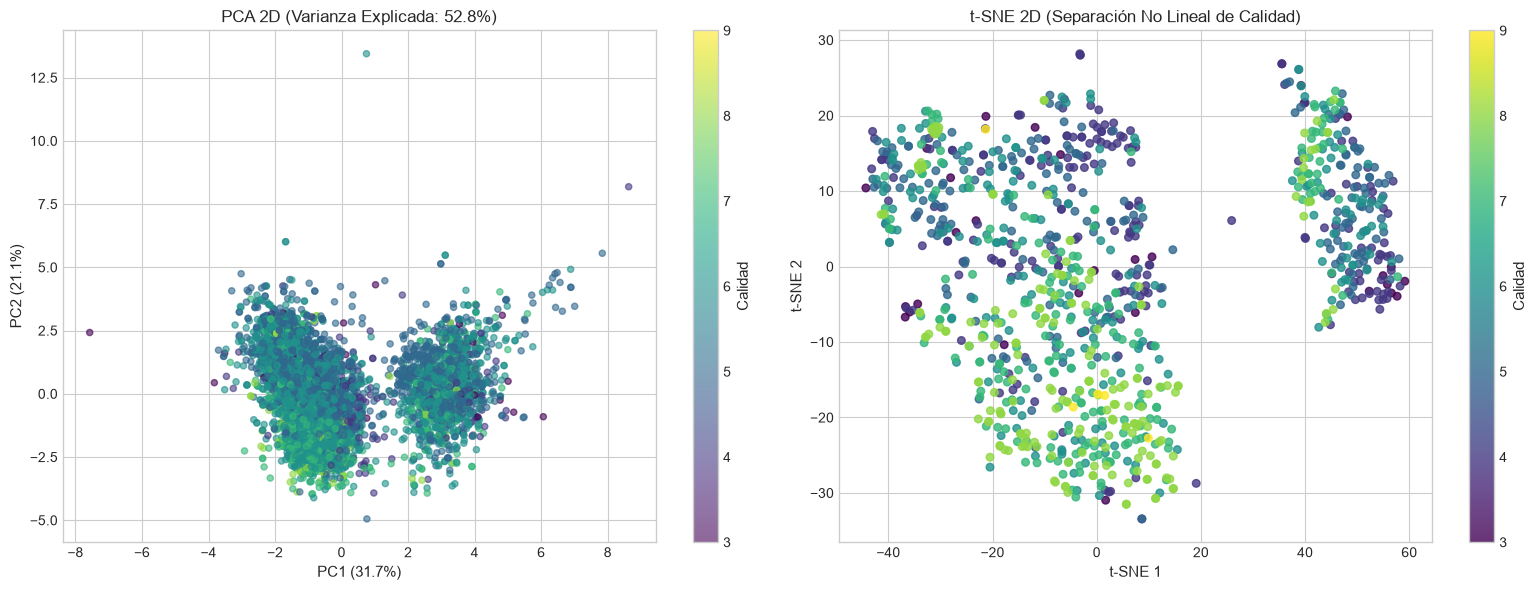

In [ ]:
# Escalado para proyección dimensional
X_features = df.drop(columns=['quality'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# 1. PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 2. t-SNE (submuestra estratificada para eficiencia computacional)
sample_idx = df.groupby('quality', group_keys=False).apply(lambda x: x.sample(min(len(x), 200), random_state=42)).index
tsne = TSNE(n_components=2, perplexity=35, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled[sample_idx])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot PCA
scatter_pca = axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1], 
    c=df['quality'], 
    cmap='viridis', 
    alpha=0.6, 
    s=20
)
axes[0].set_title(f"PCA 2D (Varianza Explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
fig.colorbar(scatter_pca, ax=axes[0], label="Calidad")

# Plot t-SNE
scatter_tsne = axes[1].scatter(
    X_tsne[:, 0], X_tsne[:, 1], 
    c=df.loc[sample_idx, 'quality'], 
    cmap='viridis', 
    alpha=0.8, 
    s=30
)
axes[1].set_title("t-SNE 2D (Separación No Lineal de Calidad)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
fig.colorbar(scatter_tsne, ax=axes[1], label="Calidad")

plt.tight_layout()
plt.show()


### Interpretación de la Proyección 2D
- **No Linealidad y Solapamiento:** Las clases de calidad exhiben un gradiente suave en el espacio físico-químico en lugar de cúmulos aislados y linealmente separables.
- **Conclusión de Modelado:** Modelos lineales simples (Regresión Logística lineal) encontrarán un límite de rendimiento estricto. Se requiere la capacidad no lineal de ensambles (*Random Forest*, *Extra Trees*, *LightGBM*, *XGBoost*) con sintonización de profundidad y regularización para capturar las superficies de decisión complejas.


### 6. Demostración de Ingeniería de Características Enológicas
Aplicamos el transformador `EnologicalFeatureEngineer` implementado en `src/features/transformers.py` y medimos el impacto en el espacio de características.


Nuevas características creadas: ['acidity_ratio', 'free_so2_ratio', 'bound_so2', 'total_acidity', 'alcohol_sugar_ratio', 'sulphates_chlorides_ratio']


,mean,std,min,50%,max
acidity_ratio,0.047612,0.022774,0.011111,0.041667,0.208000
free_so2_ratio,0.286768,0.124645,0.022727,0.269767,0.857143
bound_so2,85.219255,45.422872,3.000000,86.000000,331.000000
total_acidity,7.873606,1.388024,4.130000,7.600000,17.045000
alcohol_sugar_ratio,3.935654,2.966427,0.177812,3.531249,17.666637
sulphates_chlorides_ratio,11.059466,4.546519,1.594679,10.269993,47.139490


C:\Users\Guillen\AppData\Local\Temp\ipykernel_2960\854846686.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eng_corrs.values, y=eng_corrs.index, palette="mako")


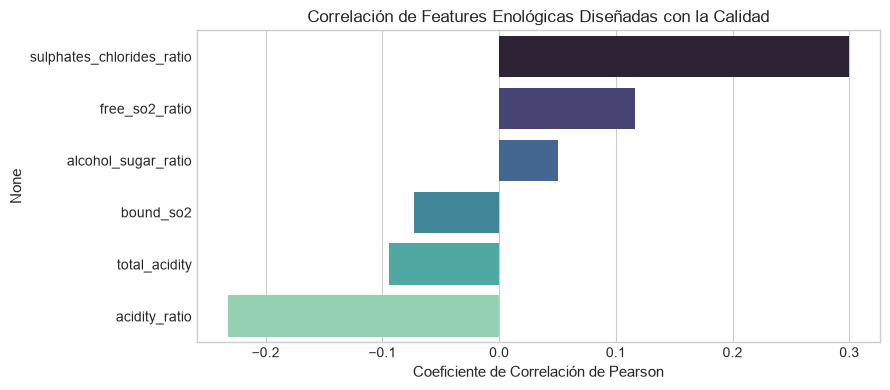

Correlaciones de las features enológicas:
sulphates_chlorides_ratio    0.299687
free_so2_ratio               0.116287
alcohol_sugar_ratio          0.050731
bound_so2                   -0.073171
total_acidity               -0.094240
acidity_ratio               -0.232446
Name: quality, dtype: float64


In [ ]:
fe_engineer = EnologicalFeatureEngineer()
df_engineered = fe_engineer.fit_transform(df.drop(columns=['quality']))
df_engineered['quality'] = df['quality']

print("Nuevas características creadas:", fe_engineer.engineered_feature_names_)
display(df_engineered[fe_engineer.engineered_feature_names_].describe().T[['mean', 'std', 'min', '50%', 'max']])

# Correlación de las nuevas variables con el target
eng_corrs = df_engineered[fe_engineer.engineered_feature_names_ + ['quality']].corr()['quality'].drop('quality').sort_values(ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(x=eng_corrs.values, y=eng_corrs.index, palette="mako")
plt.title("Correlación de Features Enológicas Diseñadas con la Calidad")
plt.xlabel("Coeficiente de Correlación de Pearson")
plt.tight_layout()
plt.show()

print("Correlaciones de las features enológicas:")
print(eng_corrs)


### Conclusiones del EDA y Roadmap para la Fase 2 (Modelado)
1. **Desbalance Multiclase:** Las clases 3, 4, 8 y 9 requieren ponderación de clases (`class_weight='balanced'`) y validación estratificada (`StratifiedKFold`).
2. **Poder de Discriminación:** La interacción entre acidez volátil, balance alcohólico y proporciones de sulfitos libres/totales añade señales no lineales valiosas que serán aprovechadas por modelos de ensamble.
3. **Prevención de Data Leakage:** El transformador `EnologicalFeatureEngineer` y los escaladores se empaquetarán en un único `Pipeline` de scikit-learn garantizando que no exista ninguna fuga de datos durante el entrenamiento o el servicio en producción.
